In [1]:
import math
import time
import matplotlib.pyplot as plt

# Списки для хранения результатов
times_g = []
times_c = []
m = 13
# Массивы для хранения норм невязок
norms_g = []
norms_c = []



Метод Гаусса

In [2]:
print ("Значения для метода Гаусса")
sizes_g = []
for n in range (1, m+1):
    sizes_g.append(n)
    G = [[0 for j in range (n+1)] for i in range (n+1)] # матрица гильберта
    B = [(-1)**(i+1) for i in range (n+1)] #правая часть

    for i in range (1,n+1):
        for j in range (1,n+1):
            G[i][j] = 1/(i+j-1)
    start = time.perf_counter()
    # прямой ход
    for k in range (1,n):
        for i in range (k+1,n+1):
            M = G[i][k] / G[k][k]
            for j in range (k, n+1):
                G[i][j] = G[i][j] - M*G[k][j]
            B[i] = B[i] - M*B[k]



    # обратный ход
    X_g = [0 for i in range (n+1)] # решения
    for i in range(n, 0, -1):
        sumX = 0
        for j in range(i + 1, n + 1):
            sumX += G[i][j] * X_g[j]
        X_g[i] = (B[i] - sumX) / G[i][i]
    end = time.perf_counter()
    times_g.append(end - start)
    print(f"n={n}: {X_g[1:]}")

    # норма невязки для Гаусса
    R_g = [0 for _ in range(n + 1)]
    for i in range(1, n + 1):
        row_sum = 0
        for j in range(1, n + 1):
            row_sum += (1 / (i + j - 1)) * X_g[j]
        R_g[i] = row_sum - B[i]

    norm_g = math.sqrt(sum(val ** 2 for val in R_g[1:]))
    norms_g.append(norm_g)  # Добавляем в массив
print ("Затраченное время")
print (times_g)


Значения для метода Гаусса
n=1: [1.0]
n=2: [10.000000000000002, -18.000000000000004]
n=3: [75.00000000000051, -408.0000000000027, 390.0000000000025]
n=4: [515.9999999999859, -5699.9999999998045, 13619.999999999485, -8819.999999999647]
n=5: [3404.9999999973443, -63479.99999995496, 273629.99999981845, -413279.999999739, 202229.99999987704]
n=6: [21918.00000161631, -618870.0000484308, 4161360.000337338, -10780560.00089496, 11865420.00100216, -4665276.000399236]
n=7: [138775.00053628907, -5526864.021581457, 53241300.20895864, -207100320.81505522, 379964971.4977107, -328592881.2963865, 107975868.42621343]
n=8: [868360.0185835361, -46383624.85056836, 604807569.67933, -3271357366.350225, 8806671831.733986, -12463050742.916435, 8871750980.661129, -2503935743.975054]
n=9: [5385734.762812614, -371634629.05276686, 6296700470.128407, -45011907294.67351, 165333740336.04794, -338039364317.5619, 388710794592.26215, -235058458139.6018, 58138631889.38808]
n=10: [33169807.63496399, -2872216155.5838323, 

Метод Холесского


In [3]:

print ("Значения для метода Холесского")
sizes_c = []
for n in range (1, m+1):
  pos_definite = True
  G = [[0 for j in range (n+1)] for i in range (n+1)] # матрица гильберта
  B = [(-1)**(i+1) for i in range (n+1)] # правая часть
  X_c = [0 for i in range (n+1)] # решения
  C = [[0 for j in range(n+1)] for i in range(n+1)]# матрица для метод Холесского
  Y = [0 for _ in range(n + 1)]
  sizes_c.append(n)
  for i in range (1,n+1):
      for j in range (1,n+1):
          G[i][j] = 1/(i+j-1)

  start = time.perf_counter()
  for i in range(1, n + 1):
      for j in range(1, i + 1):
          sumL = 0
          for k in range(1, j):
              sumL += C[i][k] * C[j][k]

          if i == j:
              Z = G[i][i] - sumL
              if Z > 1e-18:
                  C[i][j] = math.sqrt(Z)
              else:
                  print(f"При n={n} матрица не положительно определена")
                  pos_definite = False
                  break
          else:
              if C[j][j] == 0:
                  pos_definite = False
                  break
              C[i][j] = (G[i][j] - sumL) / C[j][j]

      if not pos_definite:
          break

  if not pos_definite:
      times_c.append(None)
      norms_c.append(None)
      continue
  # прямой ход C*y = B
  for i in range(1, n + 1):
      current_sum = 0
      for k in range(1, i):
          current_sum += C[i][k] * Y[k]
      Y[i] = (B[i] - current_sum) / C[i][i]

  # обратный ход Ct*x = y
  for i in range(n, 0, -1):
      current_sum = 0
      for k in range(i + 1, n + 1):
          current_sum += C[k][i] * X_c[k]
      X_c[i] = (Y[i] - current_sum) / C[i][i]
  end = time.perf_counter()
  times_c.append(end - start)
  print(f"n={n}: {X_c[1:]}")

  # норма невязки для Холесского
  R_c = [0 for _ in range(n + 1)]
  for i in range(1, n + 1):
      row_sum = 0
      for j in range(1, n + 1):
          row_sum += (1 / (i + j - 1)) * X_c[j]
      R_c[i] = row_sum - B[i]

  norm_c = math.sqrt(sum(val ** 2 for val in R_c[1:]))
  norms_c.append(norm_c)
print (times_c)

Значения для метода Холесского
n=1: [1.0]
n=2: [10.0, -18.0]
n=3: [75.00000000000028, -408.00000000000153, 390.0000000000015]
n=4: [515.9999999999613, -5699.999999999529, 13619.999999998816, -8819.999999999209]
n=5: [3404.9999999892025, -63479.99999979968, 273629.99999914103, -413279.9999987085, 202229.9999993704]
n=6: [21917.999999675085, -618869.9999923204, 4161359.9999547517, -10780559.999894477, 11865419.9998935, -4665275.999961078]
n=7: [138775.0001016725, -5526864.004029419, 53241300.03858225, -207100320.14925522, 379964970.2725342, -328592880.2347231, 107975868.07685834]
n=8: [868359.9688644409, -46383622.21629994, 604807535.6245883, -3271357183.6162333, 8806671343.306862, -12463050056.058437, 8871750494.447515, -2503935607.4242783]
n=9: [5385730.353931427, -371634325.80301225, 6296695350.4971485, -45011870818.26139, 165333606744.08606, -338039091865.09125, 388710481981.1714, -235058269455.72537, 58138585297.42037]
n=10: [33168319.820022583, -2872085123.4006615, 61306916287.4390


Сравнение значений нормы невязки методов
При n = 1: Гаусс 0.0 | Холесский 0.0
При n = 2: Гаусс 0.5 | Холесский 0.0
При n = 3: Гаусс 1.2692955176439724 | Холесский 1.4210854715202004e-14
При n = 4: Гаусс 2.496720070634791 | Холесский 3.2155493553843715e-13
При n = 5: Гаусс 4.369320090114148 | Холесский 8.134767913360665e-12
При n = 6: Гаусс 7.16499347665754 | Холесский 4.692851652099372e-10
При n = 7: Гаусс 11.292533471123502 | Холесский 1.1019557310453832e-08
При n = 8: Гаусс 17.35016543865608 | Холесский 3.29177409922697e-07
При n = 9: Гаусс 26.211438405851023 | Холесский 1.0271386732357986e-05
При n = 10: Гаусс 39.15056316788036 | Холесский 0.0002939050336343113
При n = 11: Гаусс 58.02537335424878 | Холесский 0.01295556558732578
При n = 12: Гаусс 85.54424092278597 | Холесский 0.3618503405350235
При n = 13: Гаусс 123.40101240962453 | Холесский ---


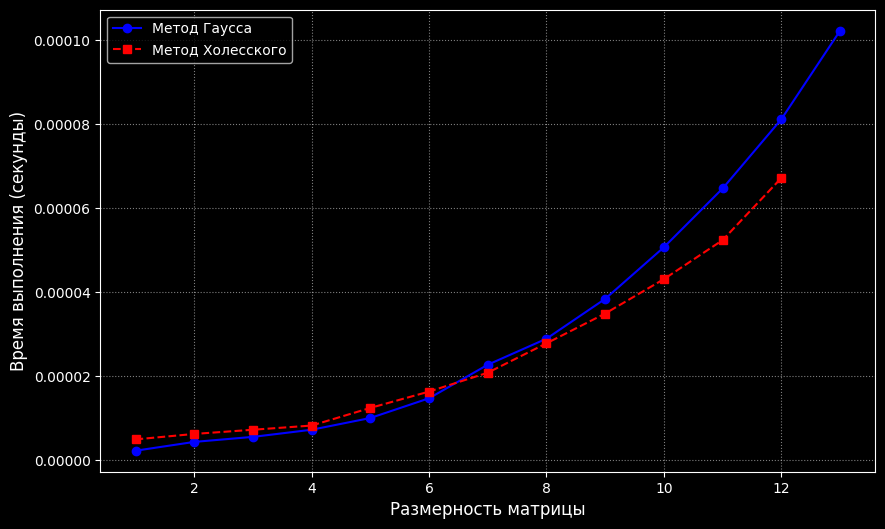

In [4]:
print("\nСравнение значений нормы невязки методов")
for i in range(m):
    n_val = i + 1

    # Обработка Гаусса
    if i < len(norms_g) and norms_g[i] is not None:
        val_g = norms_g[i]
    else:
        val_g = "---"

    # Обработка Холецкого
    if i < len(norms_c) and norms_c[i] is not None:
        val_c = norms_c[i]
    else:
        val_c = "---"

    print(f"При n = {n_val}: Гаусс {val_g} | Холесский {val_c:}")


#графики трудозатрат
plt.figure(figsize=(10, 6))
plt.plot(sizes_g, times_g, label='Метод Гаусса', color='blue', marker='o', linestyle='-')
plt.plot(sizes_c, times_c, label='Метод Холеccкого', color='red', marker='s', linestyle='--')
plt.xlabel('Размерность матрицы', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()
plt.show()